In [1]:
from shared.main import *
results_dir = f"{results_dir}/behavior"

<h1 align='center'> Memory </h1>

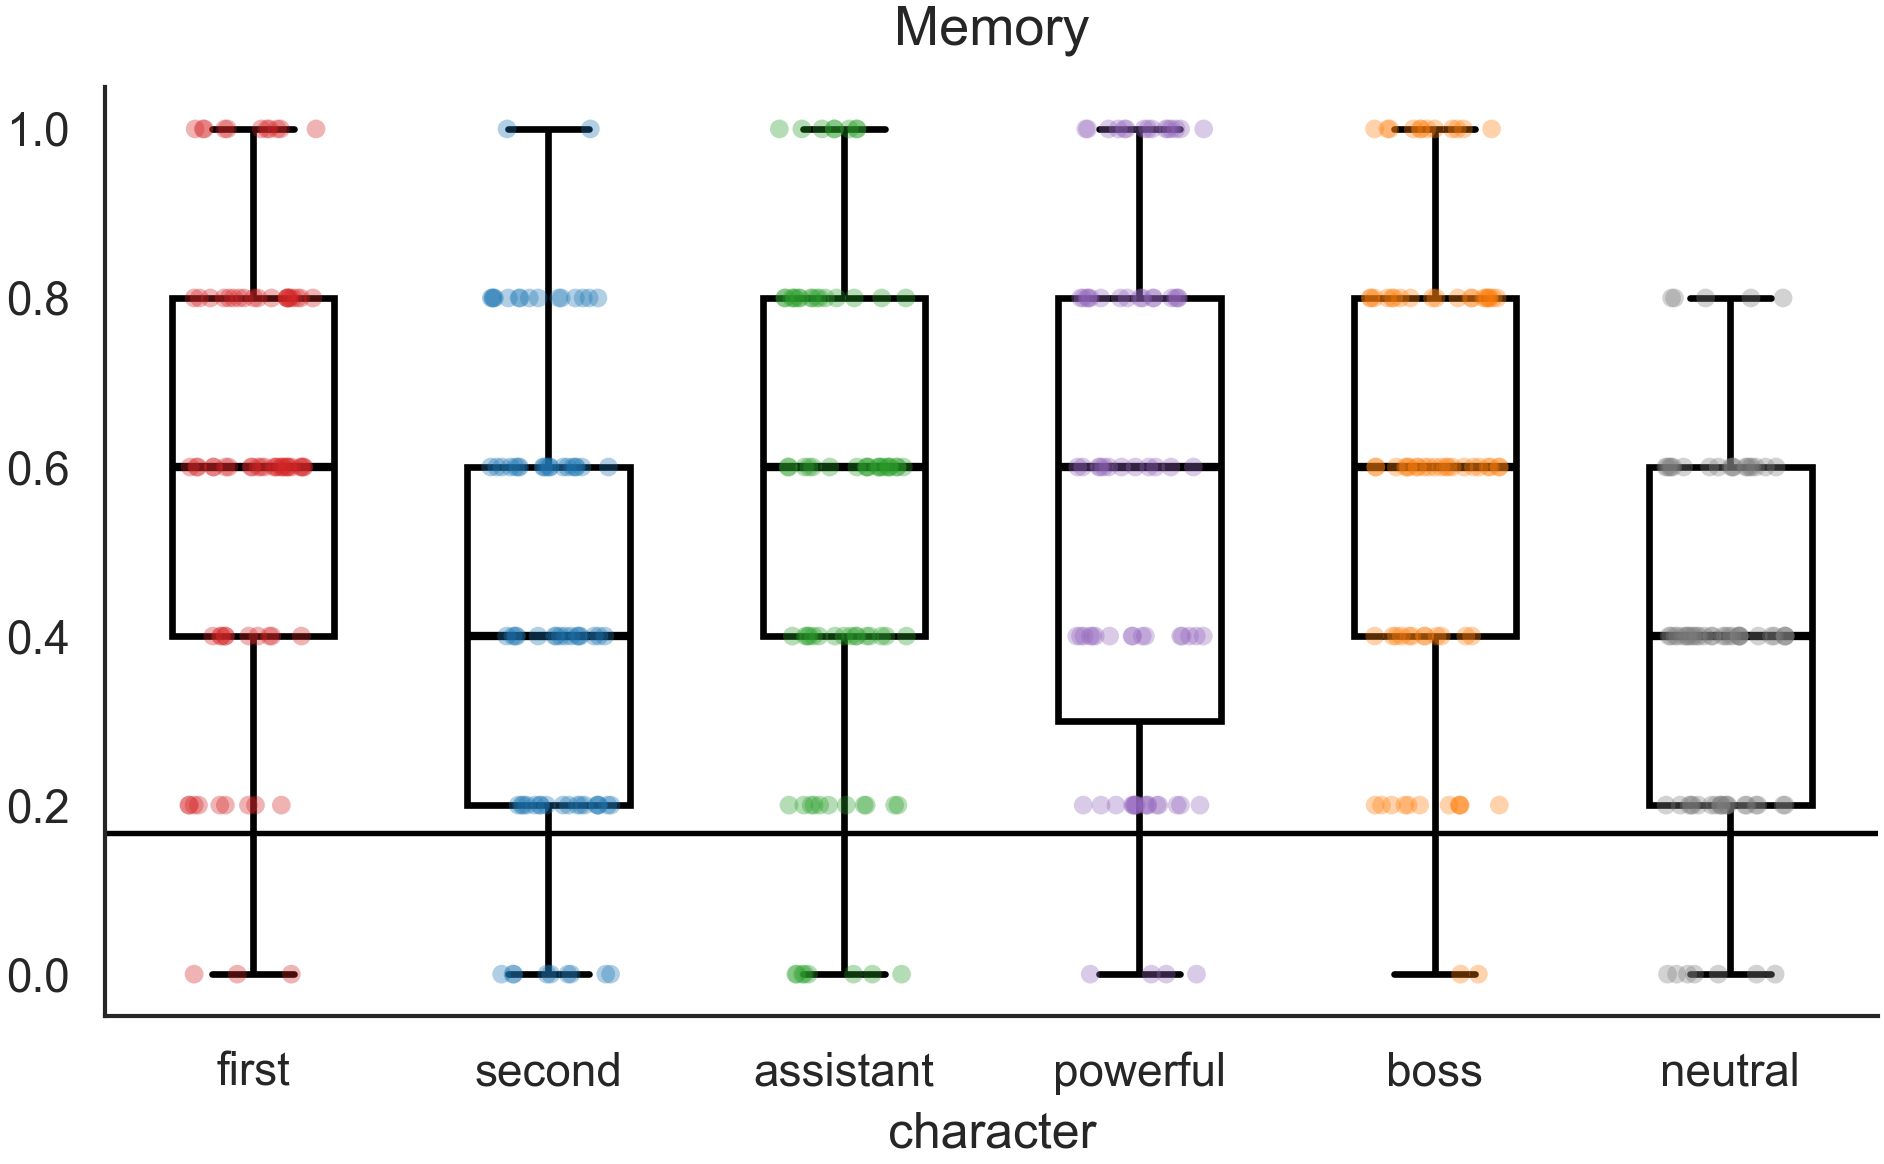

In [2]:
# prepare data for plotting
cols = [f"memory_{char}" for char in CHARACTERS]
d = (
    data[cols]
    .rename(columns=lambda c: c.replace("memory_", ""))   # "memory_first" -> "first"
    .melt(var_name="character", value_name="delta_mrl")
    .dropna()
)
order = list(CHARACTERS)
d["character"] = pd.Categorical(d["character"], categories=order, ordered=True)

# palette from your dict (must contain keys matching CHARACTERS)
palette = {c: CHARACTER_COLORS[c] for c in order}

# -----------------
# Plot (screenshot-like)
# -----------------
sns.set_style("white")
fig, ax = plt.subplots(figsize=(6.6, 4.2))

# Boxplot: black outlines, transparent fill, orange median, no fliers
sns.boxplot(
    data=d, x="character", y="delta_mrl",
    order=order,
    width=0.55,
    showfliers=False,
    boxprops=dict(facecolor="none", edgecolor="black", linewidth=1.6),
    whiskerprops=dict(color="black", linewidth=1.6),
    capprops=dict(color="black", linewidth=1.6),
    medianprops=dict(color="black", linewidth=2.0),
    ax=ax
)

# Stripplot: colored points per character
sns.stripplot(
    data=d, x="character", y="delta_mrl",
    order=order,
    palette=palette,
    jitter=0.22,
    size=4.5,
    alpha=0.35,
    linewidth=0,
    ax=ax
)

# y=0 reference line (blue)
ax.axhline(1/6, color="black", lw=1.3)

# Styling to match the attached vibe
ax.set_xlabel("character", fontsize=12)
ax.set_ylabel("", fontsize=12)  # screenshot looks like it relies on title, not y-label
ax.set_title("Memory", fontsize=13, pad=10)

# keep only left/bottom spines (thin)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# optional: set symmetric-ish limits like the screenshot (comment out if you prefer auto)
# ax.set_ylim(-0.8, 0.8)

plt.tight_layout()
plt.show()


<h1 align='center'> Confusability as a function of abstract distance </h1>

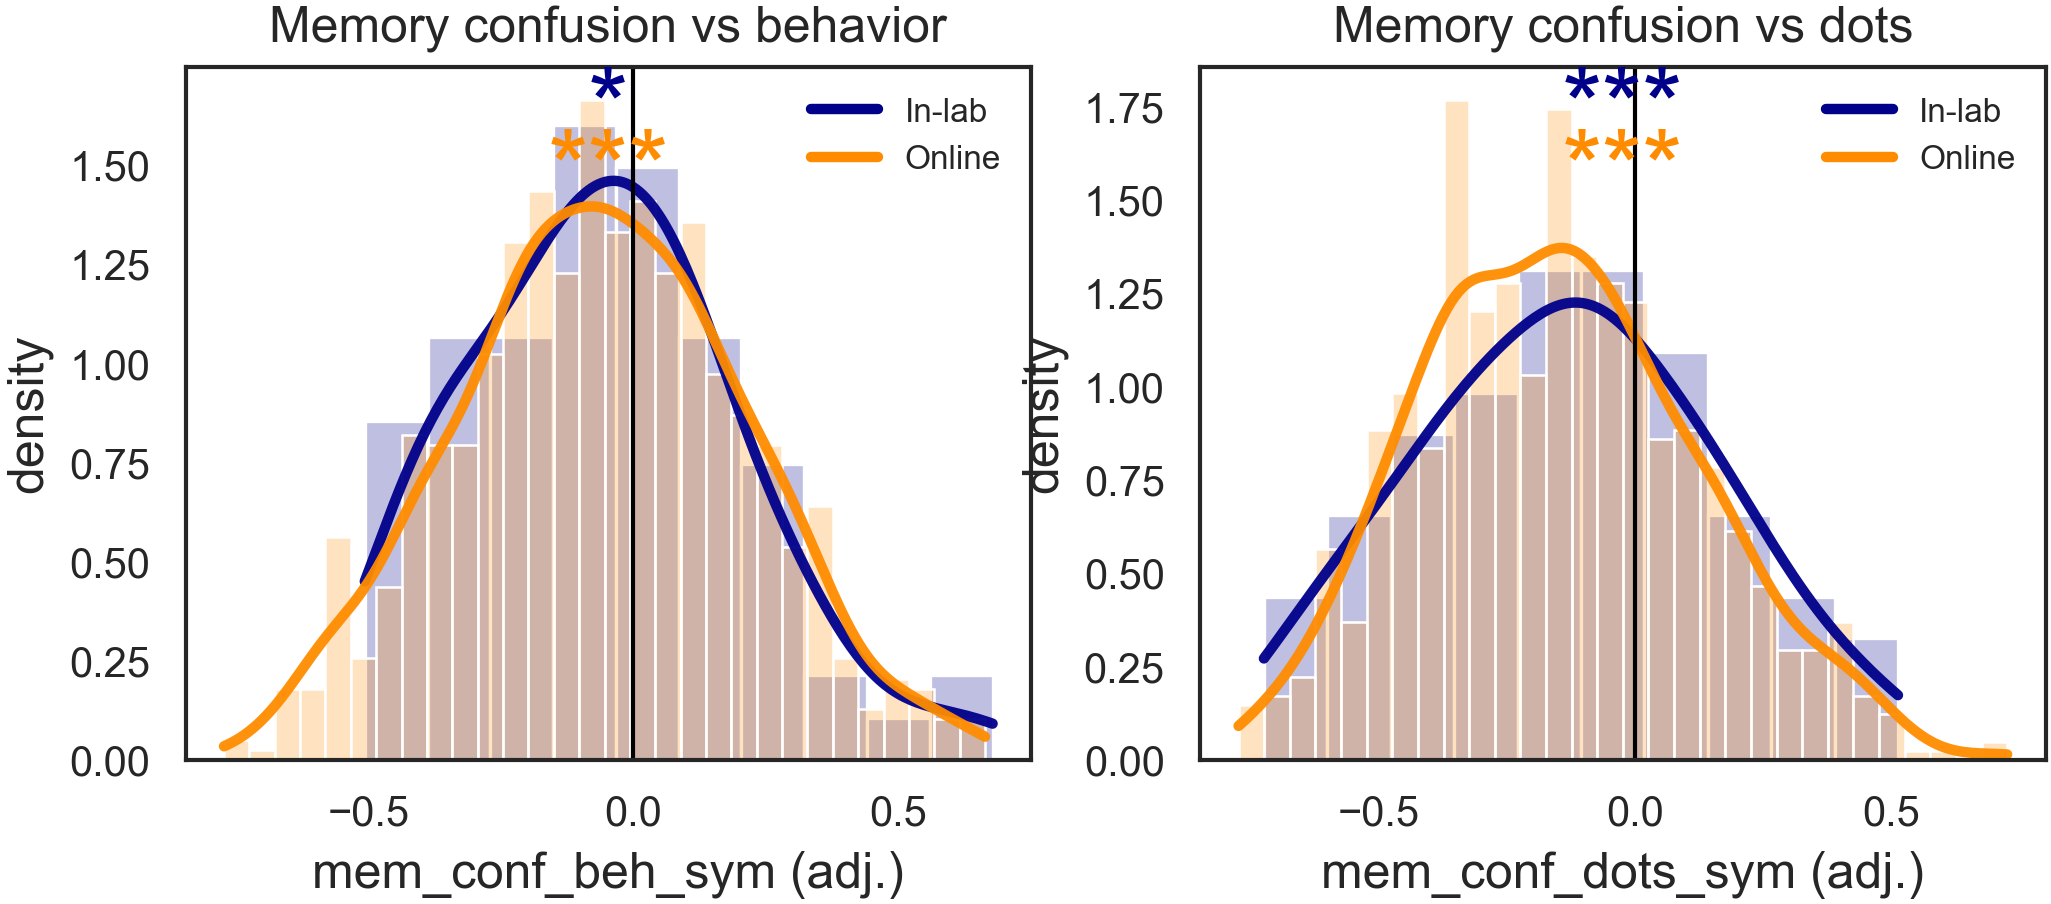

In [3]:
covariates = ['dx', 'sex', 'ctq_score', 'age_years', 'missing_trials']

fig, axs = plt.subplots(1, 2, figsize=(8, 3))

ax = axs[0]
ax.set_title("Memory confusion vs behavior")
histplot_samples(
    data,
    data_online,
    x="mem_conf_beh_sym",
    tail='less',
    covariates=covariates,  
    ax=ax,
)

ax = axs[1]
ax.set_title("Memory confusion vs dots")
histplot_samples(
    data,
    data_online,
    x="mem_conf_dots_sym",
    covariates=covariates,  
    tail='less',
    ax=ax,
);

## symmeterized ~= directed
as a map-level feature within and across subject effects 

In [4]:
run_regression('mem_conf_beh_sym ~ mem_conf_beh_dir', data=mem_conf)


,y,x,dof,rsq,adj_rsq,bic,aic,beta,se,95%_lb,95%_ub,t,p,p_left,p_right
0,mem_conf_beh_sym,Intercept,77.0,0.935,0.934,-192.95,-197.69,-0.055,0.008,-0.07,-0.04,-7.153,0.0,0.0,1.0
1,mem_conf_beh_sym,mem_conf_beh_dir,77.0,0.935,0.934,-192.95,-197.69,0.255,0.008,0.24,0.27,33.166,0.0,1.0,0.0


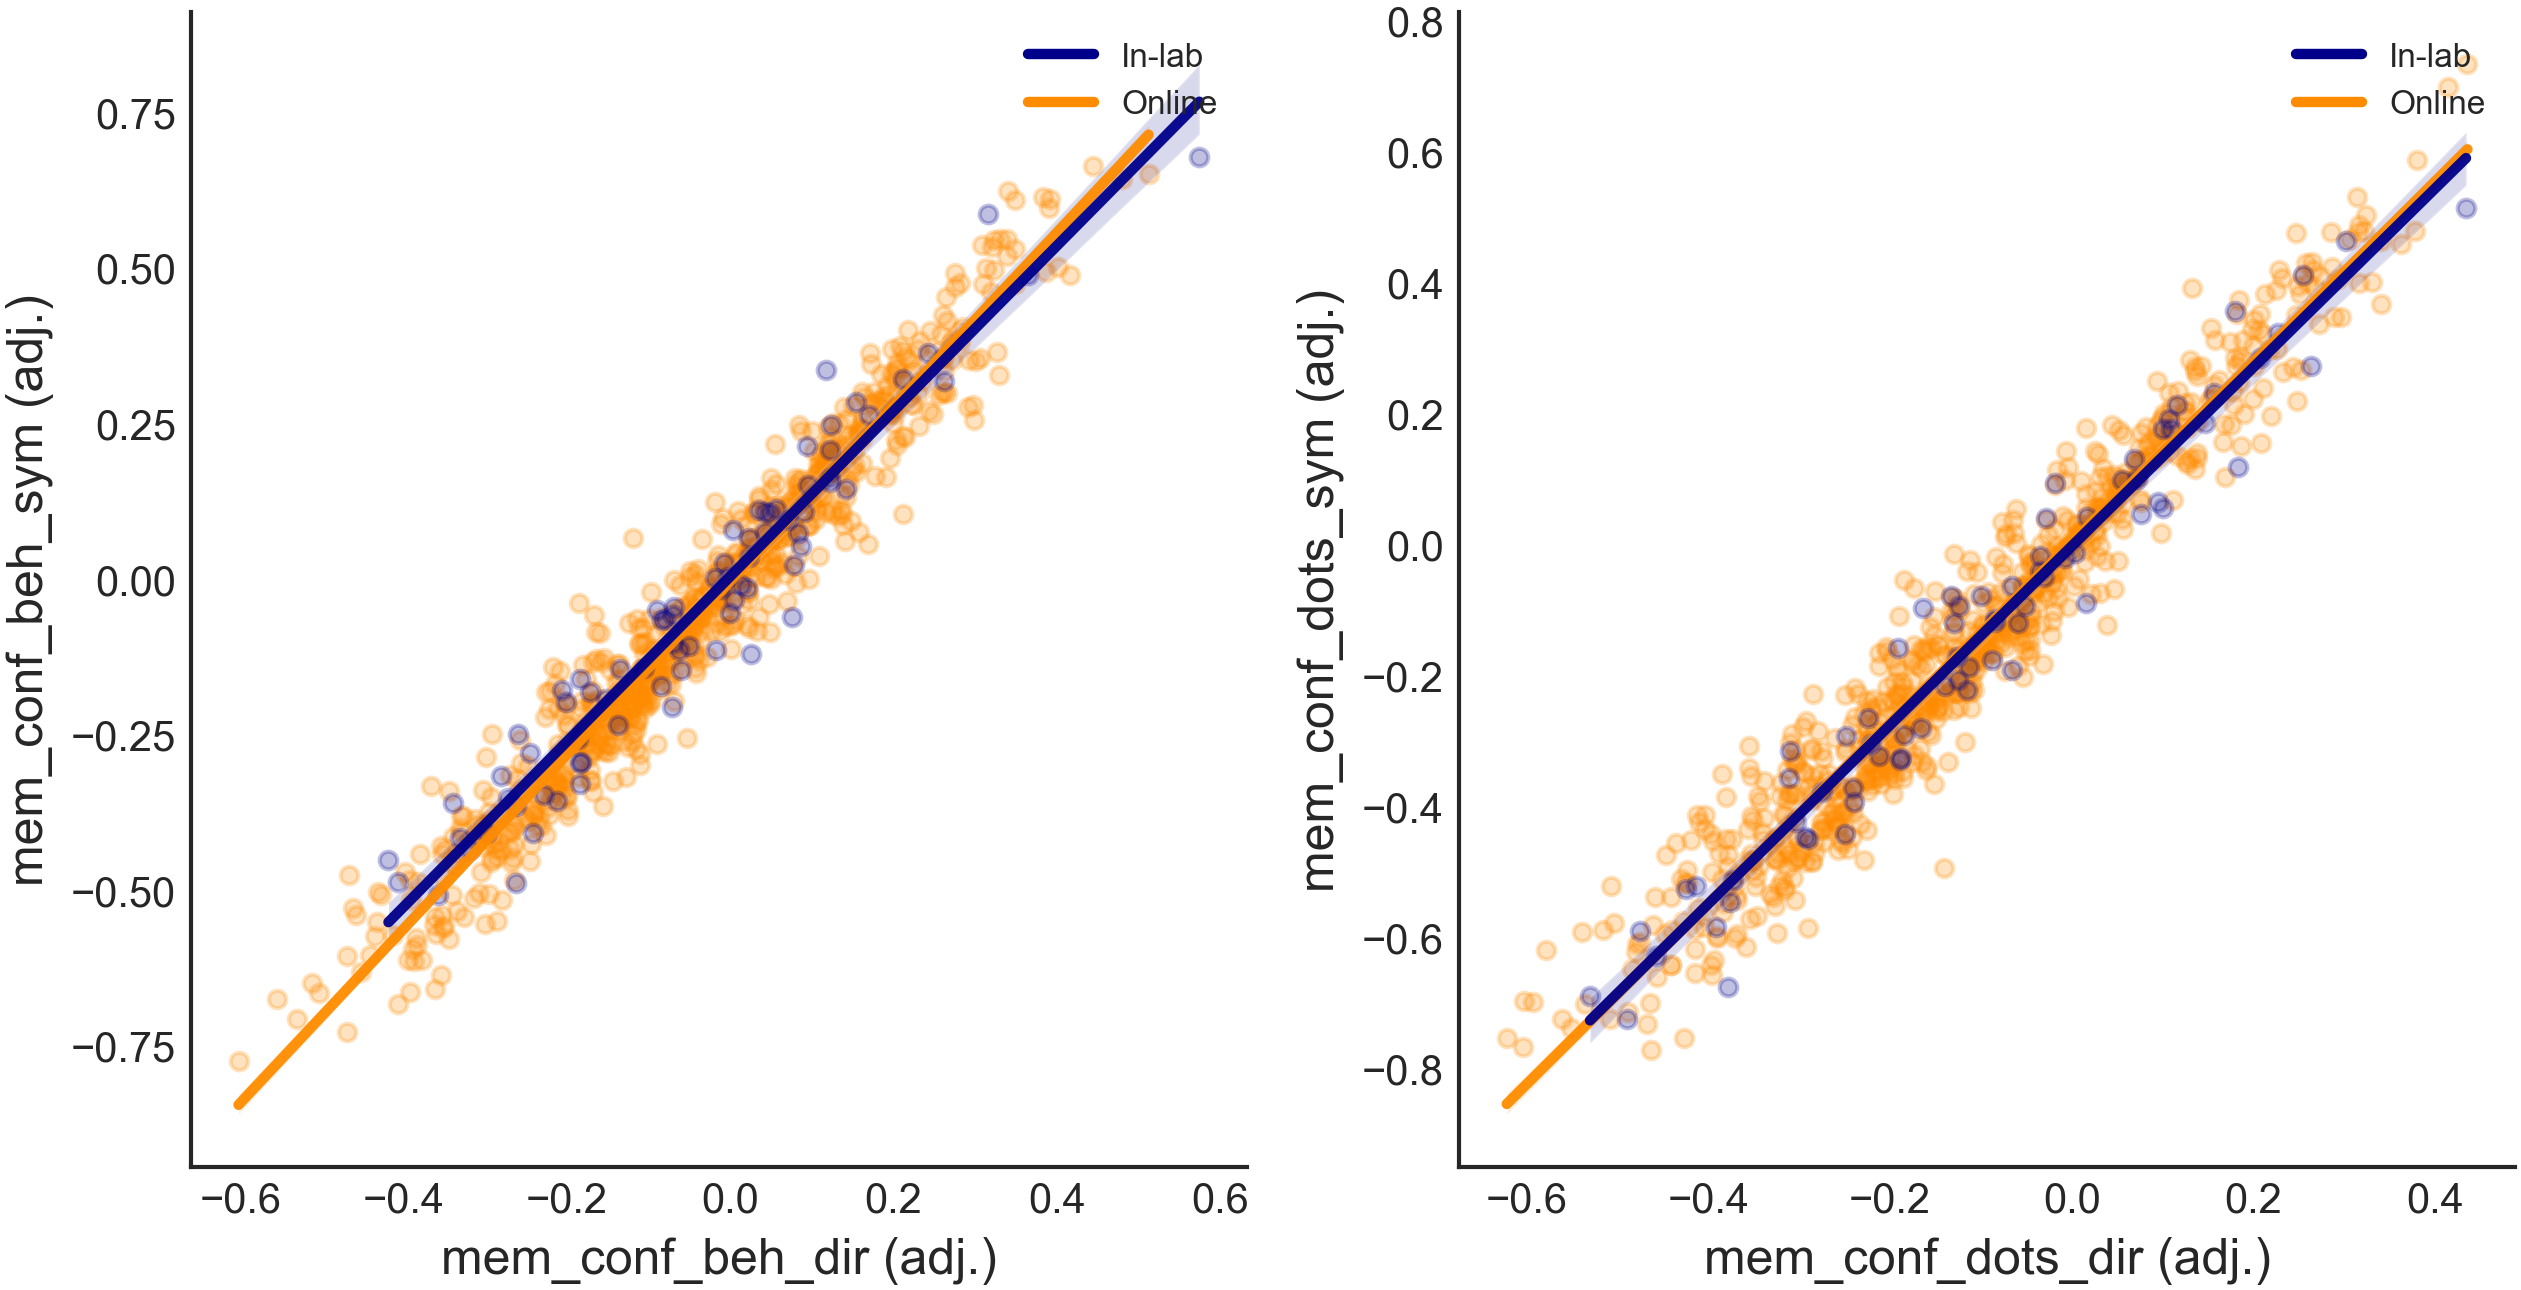

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ax = axs[0]
regplot_samples(data,
                data_online,
                x="mem_conf_beh_dir",
                y="mem_conf_beh_sym",
                covariates=covariates, 
                annotate=False,
                ax=ax)

ax = axs[1]
regplot_samples(data,
                data_online,
                x="mem_conf_dots_dir",
                y="mem_conf_dots_sym",
                covariates=covariates, 
                annotate=False,
                ax=ax);

## is any specific character pair driving this?
not hugely - but the online and in-person samples have similar across pairs importances... i.e., same character pairs tended to contribute to the distance–confusion relationship across datasets

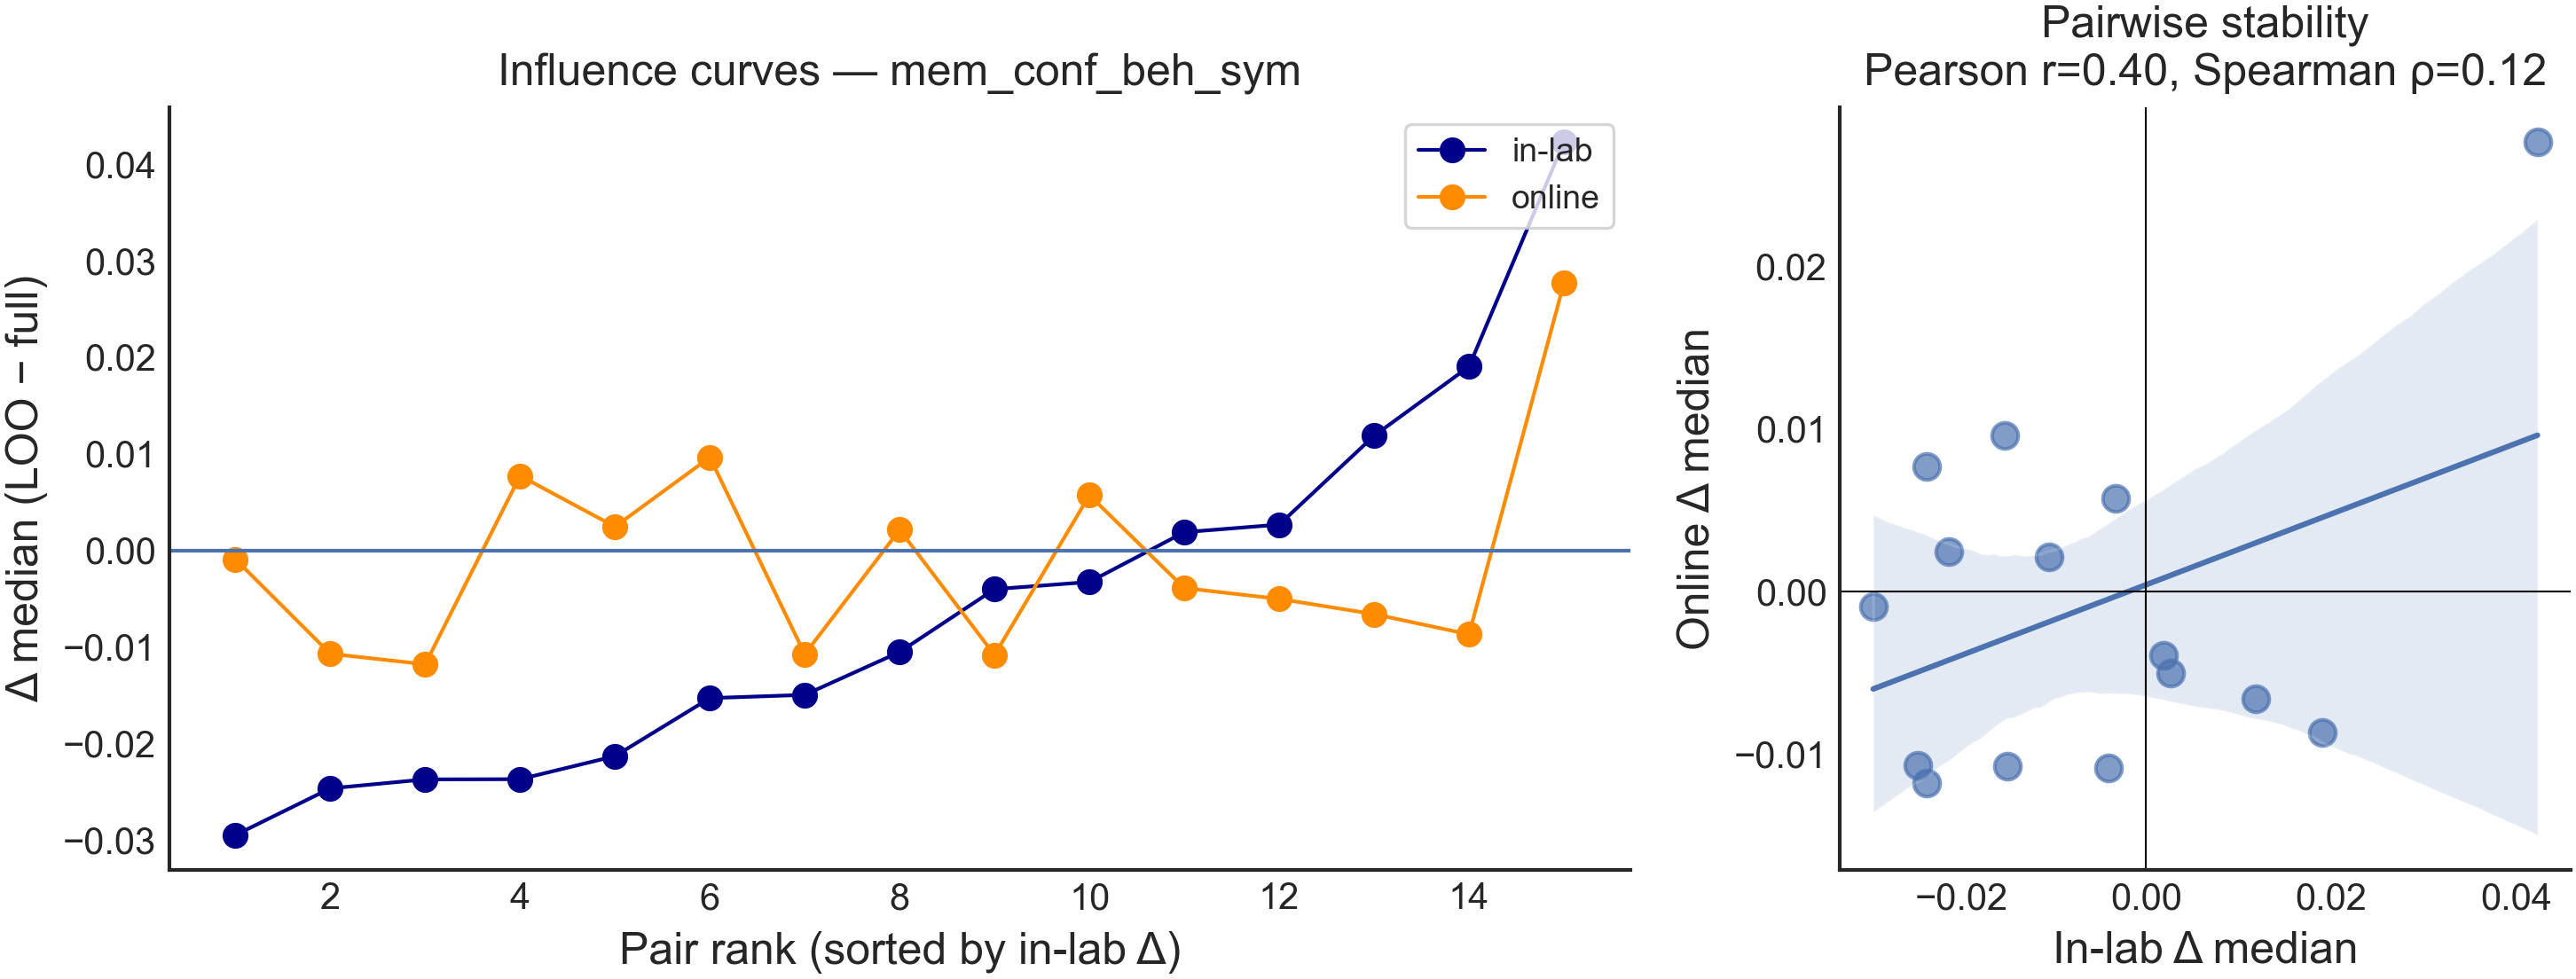

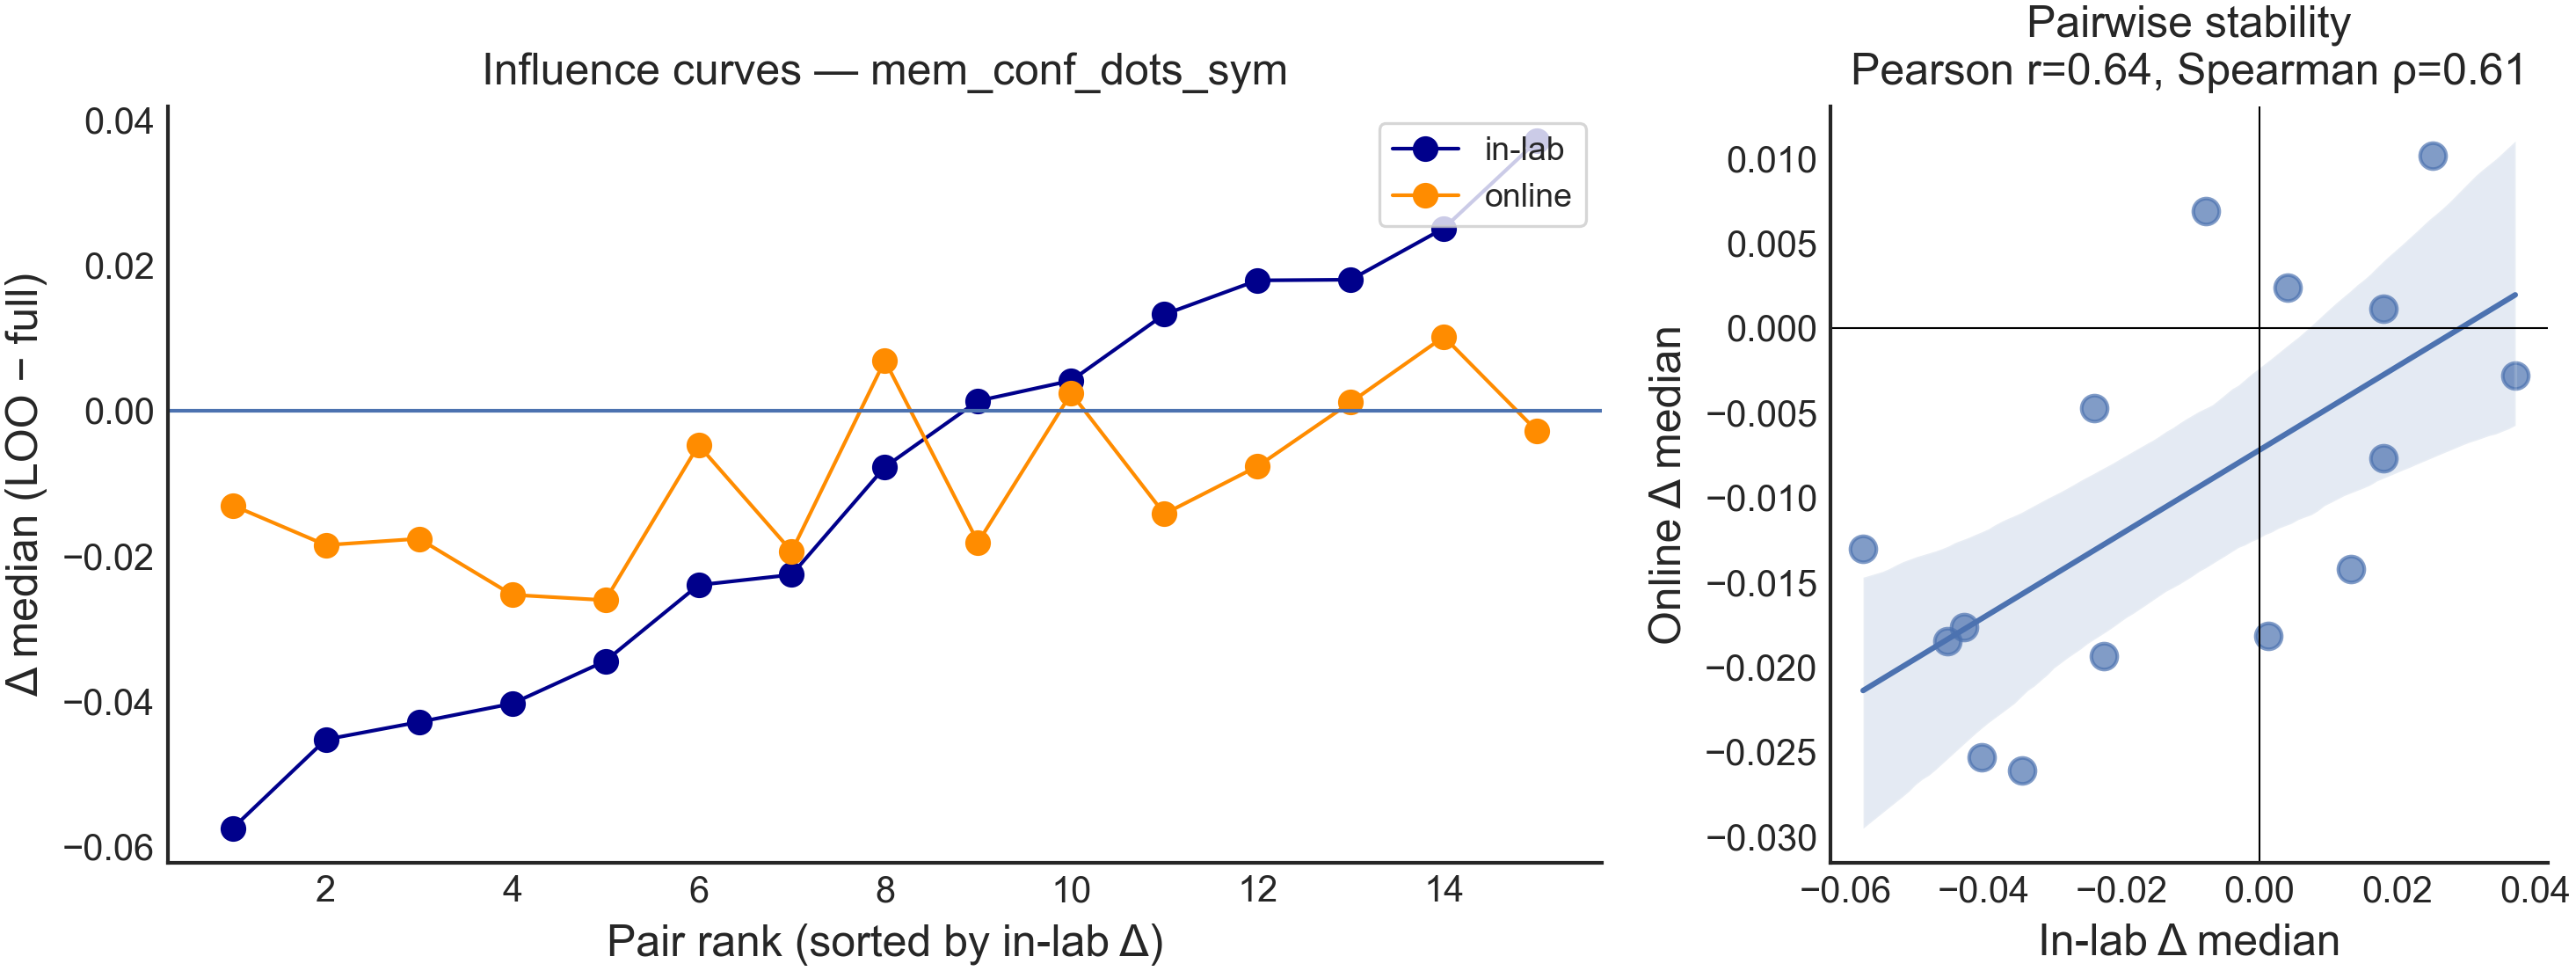

In [6]:
from scipy.stats import pearsonr, spearmanr

def plot_influence_line_and_scatter(inlab, online, measure, *, y="delta_median"):
    # Align pairs across samples
    A = inlab.query("measure == @measure")[["omit_pair_k", "pair", y]].rename(columns={y: "inlab"})
    B = online.query("measure == @measure")[["omit_pair_k", y]].rename(columns={y: "online"})
    W = A.merge(B, on="omit_pair_k", how="inner").sort_values("inlab").reset_index(drop=True)
    W["rank"] = np.arange(1, len(W) + 1)

    # Correlations for scatter title
    x = W["inlab"].to_numpy(float)
    z = W["online"].to_numpy(float)
    r_p = pearsonr(x, z)[0]
    r_s = spearmanr(x, z).correlation

    lim = np.nanmax(np.abs(np.r_[x, z])) * 1.05

    # --- Single figure with 2 subplots ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[2, 1])

    # Left: overlaid influence curves
    ax1.plot(W["rank"], W["inlab"], marker="o", label="in-lab", color=sample_colors[0])
    ax1.plot(W["rank"], W["online"], marker="o", label="online", color=sample_colors[1])
    ax1.axhline(0, linewidth=1)
    ax1.set_xlabel("Pair rank (sorted by in-lab Δ)")
    ax1.set_ylabel("Δ median (LOO − full)")
    ax1.set_title(f"Influence curves — {measure}")
    ax1.legend()

    # Right: per-pair scatter
    sns.regplot(x="inlab", y="online", data=W, ax=ax2, 
                scatter_kws={"s": 50, 'edgecolor': None, "alpha": 0.7})
    # ax2.plot([-lim, lim], [-lim, lim], color='black', linewidth=0.5, linestyle='--')  # identity
    ax2.axhline(0, linewidth=0.5, linestyle='-', color='black')
    ax2.axvline(0, linewidth=0.5, linestyle='-', color='black')
    # ax2.set_xlim(-lim, lim)
    # ax2.set_ylim(-lim, lim)
    ax2.set_xlabel("In-lab Δ median")
    ax2.set_ylabel("Online Δ median")
    ax2.set_title(f"Pairwise stability\nPearson r={r_p:.2f}, Spearman ρ={r_s:.2f}")

    plt.tight_layout()
    plt.show()

    return W

# --- Usage ---
inlab  = pd.read_csv("../results/behavior/mem_conf_inlab_loo_pair_influence.csv")
online = pd.read_csv("../results/behavior/mem_conf_online_loo_pair_influence.csv")

for df in (inlab, online):
    df["pair"] = df["omit_char_1"] + "–" + df["omit_char_2"]

W = plot_influence_line_and_scatter(inlab, online, "mem_conf_beh_sym")
W = plot_influence_line_and_scatter(inlab, online, "mem_conf_dots_sym")


## there is no association between memory and confusability

<Axes: xlabel='memory_mean (adj.)', ylabel='mem_conf_beh_sym (adj.)'>

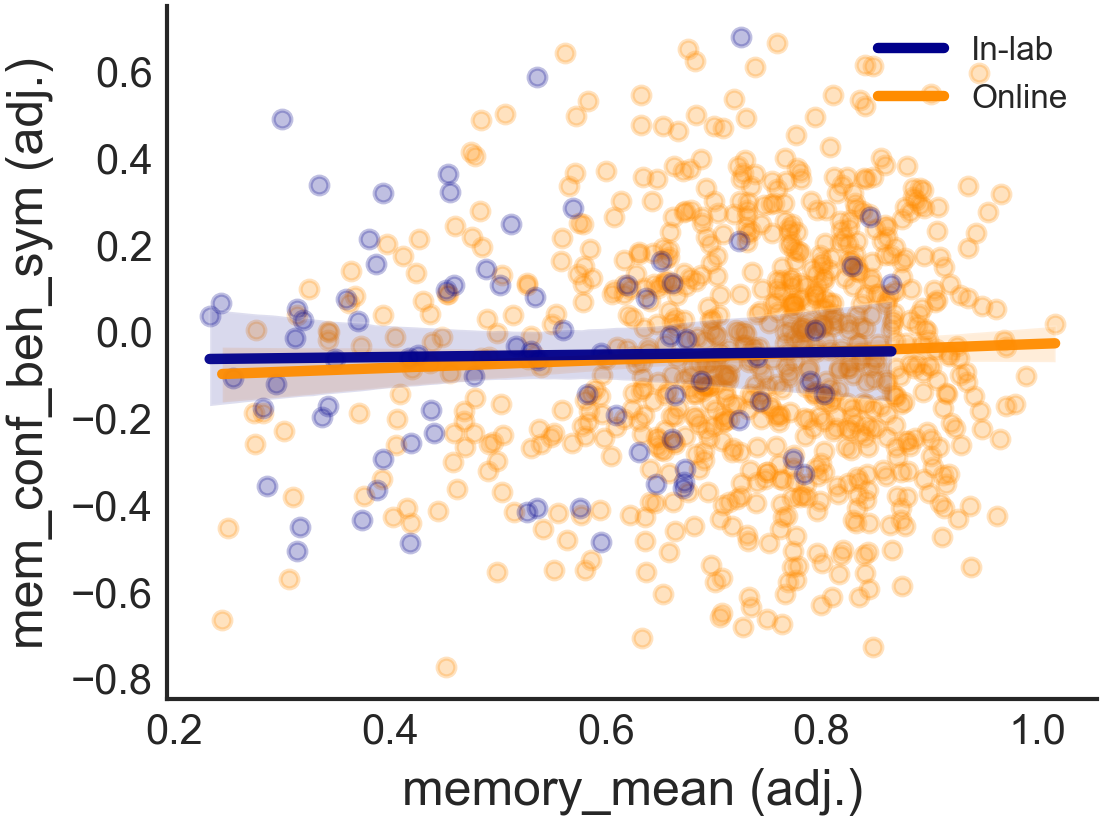

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
regplot_samples(data, data_online, 
                y="mem_conf_beh_sym", x="memory_mean", 
                covariates=covariates, ax=ax)

## geometry that could explain it... doesnt?

In [ ]:
# its not these different measures of dots mapping geometry
def dots_hull_area(coords):
    # if nans or insufficient points, return nan
    if np.isnan(coords).any() or coords.shape[0] < 3:
        return np.nan
    return ConvexHull(coords).volume

def min_pw_distance(coords):
    # if nans or insufficient points, return nan
    if np.isnan(coords).any() or coords.shape[0] < 2:
        return np.nan
    D = pdist(coords)
    return float(np.min(D))

def avg_pw_distance(coords):
    # if nans or insufficient points, return nan
    if np.isnan(coords).any() or coords.shape[0] < 2:
        return np.nan
    D = pdist(coords)
    return float(np.mean(D))

for df in [mem_df, mem_df_online]:
    dots_coords = get_coords(df, which='dots')
    df['dots_avg_pw_dist'] = [avg_pw_distance(coords) for coords in dots_coords]
    df['dots_min_pw_dist'] = [min_pw_distance(coords) for coords in dots_coords]
    print_df(run_regression('mem_conf_dots ~ dots_min_pw_dist + dots_avg_pw_dist + memory_mean', data=df, scale_x=True, scale_y=True))

<h1 align='center'> Associations with other measures of confusability </h1>

In [ ]:
df_geom = summarize_behavior_cols(
    incl_subs,
    cols=None,
    coord_fns={
        "nn_mean": lambda coords, df: nn_mean(coords, df),
        "nn_min":  lambda coords, df: nn_min(coords, df),
    },
)
df_geom_online = summarize_behavior_cols(
    incl_subs_online,
    cols=None,
    coord_fns={
        "nn_mean": lambda coords, df: nn_mean(coords, df),
        "nn_min":  lambda coords, df: nn_min(coords, df),
    },
)

In [ ]:
load_pickle("../analyses/lsa_decision_spm/subject_data_tavares.pkl")
from sklearn.metrics.pairwise import cosine_similarity
def neural_confusability_from_betas_by_char(
    betas_by_char: dict,
    *,
    agg="mean",          # how to summarize trials within a character: "mean" or "median"
    normalize=True,      # unit-normalize character prototypes before similarity
    top_k=1,             # 1 = nearest-neighbor; >1 = average of top-k neighbors
    return_details=False
):
    """
    Compute a simple, interpretable neural confusability metric from ROI betas organized by character.

    betas_by_char: dict {character -> array (n_trials, n_voxels)} or list of arrays
                   If list, characters are enumerated 0..K-1.

    Returns:
      conf_scalar: float
        Average (across characters) of mean cosine similarity to their top-k most similar other characters.
        Higher => more confusable / less separable.

      If return_details=True, also returns a dict with:
        - chars: list of character keys
        - prototypes: (K, V) prototype vectors
        - sim_matrix: (K, K) cosine similarity matrix (diag=1)
        - per_char_conf: (K,) confusability per character
    """
    if betas_by_char is None:
        return (np.nan, {}) if return_details else np.nan

    # Accept dict or list/tuple
    if isinstance(betas_by_char, dict):
        chars = list(betas_by_char.keys())
        mats = [np.asarray(betas_by_char[c]) for c in chars]
    else:
        mats = [np.asarray(m) for m in betas_by_char]
        chars = list(range(len(mats)))

    # Need >=2 characters
    if len(mats) < 2:
        return (np.nan, {}) if return_details else np.nan

    # Build prototype per character
    protos = []
    for m in mats:
        if m.ndim != 2 or m.shape[0] == 0:
            protos.append(None)
            continue
        if agg == "median":
            p = np.nanmedian(m, axis=0)
        else:
            p = np.nanmean(m, axis=0)
        protos.append(p)

    # Drop characters with invalid prototypes
    keep = [i for i, p in enumerate(protos) if p is not None and np.all(np.isfinite(p))]
    if len(keep) < 2:
        return (np.nan, {}) if return_details else np.nan

    chars = [chars[i] for i in keep]
    P = np.vstack([protos[i] for i in keep]).astype(float)  # (K,V)

    # Optional unit normalization (recommended for interpretability)
    if normalize:
        norms = np.linalg.norm(P, axis=1, keepdims=True)
        norms = np.where(norms == 0, 1.0, norms)
        P = P / norms

    # Similarity matrix between character prototypes
    S = cosine_similarity(P)  # (K,K), diag=1

    # For each character, compute mean similarity to top-k other characters
    K = S.shape[0]
    k_eff = int(max(1, min(top_k, K - 1)))

    per_char = np.full(K, np.nan)
    for i in range(K):
        others = np.delete(S[i], i)  # drop self
        # take top-k similarities
        top = np.partition(others, -k_eff)[-k_eff:]
        per_char[i] = float(np.mean(top))

    conf_scalar = float(np.mean(per_char))

    if not return_details:
        return conf_scalar

    details = {
        "chars": chars,
        "prototypes": P,
        "sim_matrix": S,
        "per_char_conf": per_char,
    }
    return conf_scalar, details

results = {}
for sub_id in incl_subs:

    try: 
        betas = subject_data[sub_id]['roi_betas']['HPC-L']
        betas_by_char = organize_by_character(betas)

        conf_nn, det = neural_confusability_from_betas_by_char(
            betas_by_char,
            top_k=1,              # nearest-neighbor confusability
            return_details=True
        )

        conf_top2 = neural_confusability_from_betas_by_char(
            betas_by_char,
            top_k=2               # smoother: mean of top-2 neighbors
        )
        results[sub_id] = {
            "conf_nn": conf_nn,
            "conf_top2": conf_top2,
        }
    except KeyError:
        results[sub_id] = {
            "conf_nn": np.nan,
            "conf_top2": np.nan,
        }
neural_df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index':'sub_id'})

In [ ]:
vars = ['mapping_score_distance_z', 'mem_conf_dots', 'beta_decision_num']
for var in vars:
    print_df(run_regression(f'{var}  ~ ctq_score * dx + sex + memory_mean', 
                        data=data, scale_x=True, scale_y=True))